In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1,2,3"
from util import *

device = "cuda"

from utils_pus import generate_sparse_mask, remove_adapter, insert_adapter

In [2]:
def seed_everything(seed: int):
    import random, os
    import numpy as np
    import torch
    
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True
    
seed_everything(3141592653)

In [3]:
img_siren = Siren(in_features=2, out_features=3, hidden_features=256,
                  hidden_layers=3, outermost_linear=True).to(device)

sparse_mask = generate_sparse_mask(img_siren.cpu(), sparse_ratio=0.3)
img_siren.cuda()

Siren(
  (net): Sequential(
    (0): SineLayer(
      (linear): Linear(in_features=2, out_features=256, bias=True)
    )
    (1): SineLayer(
      (linear): Linear(in_features=256, out_features=256, bias=True)
    )
    (2): SineLayer(
      (linear): Linear(in_features=256, out_features=256, bias=True)
    )
    (3): SineLayer(
      (linear): Linear(in_features=256, out_features=256, bias=True)
    )
    (4): Linear(in_features=256, out_features=3, bias=True)
  )
)

In [4]:
img = get_image_tensor('/home/comp/csqsong/pro2025/quINR/siren/data/DIV2K-test/0801.png',256)

img = ImageFitting(256,img)

dataloader = DataLoader(img, batch_size=1, pin_memory=True, num_workers=0)

model_input, ground_truth = next(iter(dataloader))
model_input, ground_truth = model_input.cuda(), ground_truth.cuda()

/home/comp/csqsong/.conda/envs/sam/lib/python3.10/site-packages/torch/functional.py:512: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3587.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.03173554..0.9310537].


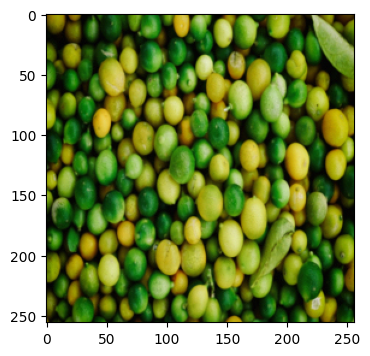

In [5]:
ckpt = torch.load("siren.pt")
img_siren.load_state_dict(ckpt)

model_output, coords = img_siren(model_input)
fig, axes = plt.subplots(1,1, figsize=(4,4))
axes.imshow(model_output.cpu().view(256,256,3).detach().numpy()*0.5 + 0.5)
plt.show()


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.035474658..1.0164142].


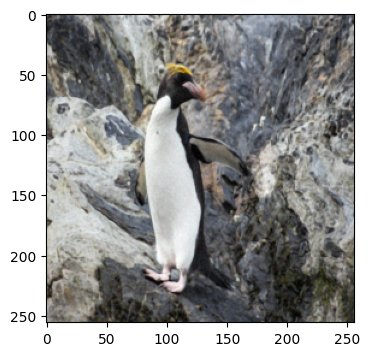

In [6]:
remove_adapter(img_siren.cuda(), sparse_mask)

model_output, coords = img_siren(model_input)
fig, axes = plt.subplots(1,1, figsize=(4,4))
axes.imshow(model_output.cpu().view(256,256,3).detach().numpy()*0.5 + 0.5)
plt.show()

